## 1. Business Problem Understanding

Customer churn is a big problem for subscription businesses like telecom companies. Churn means customers stop using their service.

### Why Churn Hurts Business:

*   **Revenue Loss:** Churning customers mean lost income. This directly impacts profits and growth.
*   **High Acquisition Cost:** Getting new customers costs more than keeping old ones. High churn forces more spending on marketing and sales to replace lost customers.
*   **Bad Reputation:** Many customers leaving can signal dissatisfaction. This can hurt the company's brand and make it harder to attract new customers.
*   **Competitive Disadvantage:** In competitive markets, high churn can mean losing market share to rivals.

### Why Predicting Churn Helps:

Predicting churn lets companies find high-risk customers *before* they leave. This allows for targeted efforts to keep them.

### Why Customer Retention Matters:

*   **Cost-Effective:** Keeping existing customers is cheaper than finding new ones. Loyal customers often spend more over time.
*   **More Revenue:** Retained customers tend to buy more, upgrade services, and refer new people. This boosts overall revenue.
*   **Customer Loyalty:** Good retention strategies build strong customer relationships and a stable customer base.

### Why Missing Churners (False Negatives) Can Be Worse Than False Alarms (False Positives):

In churn prediction:

*   **False Negative (FN):** We predict a customer *won't* churn, but they *do*. This is costly. We lose a customer without a chance to intervene. This means direct revenue loss.
*   **False Positive (FP):** We predict a customer *will* churn, but they *don't*. This means we might spend money (like discounts) on customers who would have stayed anyway. This costs money, but it's usually less severe than losing a customer entirely. The customer is still retained.

So, a model that catches more potential churners (minimizes false negatives) is often better. This is true even if it means some false positives. The main goal is to identify as many at-risk customers as possible for timely retention efforts.



## 2. Data Understanding

To begin our data understanding phase, we first need to load the dataset into a pandas DataFrame. Based on the file list provided, the relevant file appears to be `/content/part_3_customer_churn_prediction.csv`.

In [28]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/part_3_customer_churn_prediction.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display the basic information about the DataFrame (columns, non-null counts, dtypes)
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

First 5 rows of the dataset:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TEL00001,Male,0,Yes,No,42,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,One year,Yes,Electronic check,102.95,4306.99,No
1,TEL00002,Female,0,No,Yes,55,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,One year,No,Credit card,120.39,6588.83,No
2,TEL00003,Female,0,Yes,Yes,0,Yes,No,DSL,No,...,Yes,No,No,Yes,Two year,No,Mailed check,74.42,0.00,Yes
3,TEL00004,Female,0,No,Yes,16,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,83.24,1324.06,No
4,TEL00005,Male,0,Yes,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,25.44,123.68,Yes



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1800 non-null   object 
 1   Gender            1800 non-null   object 
 2   SeniorCitizen     1800 non-null   int64  
 3   Partner           1800 non-null   object 
 4   Dependents        1800 non-null   object 
 5   Tenure            1800 non-null   int64  
 6   PhoneService      1800 non-null   object 
 7   MultipleLines     1800 non-null   object 
 8   InternetService   1800 non-null   object 
 9   OnlineSecurity    1800 non-null   object 
 10  OnlineBackup      1800 non-null   object 
 11  DeviceProtection  1800 non-null   object 
 12  TechSupport       1800 non-null   object 
 13  StreamingTV       1800 non-null   object 
 14  StreamingMovies   1800 non-null   object 
 15  Contract          1800 non-null   object 
 16  PaperlessBilling  1800 no

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,1800,1800,1800.000000,1800,1800,1800.000000,1800,1800,1800,1800,...,1800,1800,1800,1800,1800,1800,1800,1800.000000,1769.000000,1800
unique,1800,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,TEL01800,Male,NaN,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,915,NaN,909,924,NaN,1630,834,767,715,...,713,733,712,722,968,906,627,NaN,NaN,1153
mean,NaN,NaN,0.162778,NaN,NaN,22.603889,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.462250,1699.169503,NaN
std,NaN,NaN,0.369265,NaN,NaN,20.165802,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.532909,1780.084580,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,0.000000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.150000,383.650000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,16.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.665000,1077.400000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,33.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.567500,2436.040000,NaN


### Dataset Explanation:

The dataset contains **1800 rows** and **21 columns**, providing various details about customer demographics, services, and billing information, along with their churn status. Below is a breakdown of the important columns:

*   **CustomerID**: A unique identifier for each customer. This column is irrelevant for model training and will likely be dropped during preprocessing.
*   **Gender**: Customer's gender (Male/Female).
*   **SeniorCitizen**: Indicates if the customer is a senior citizen (1) or not (0).
*   **Partner**: Indicates if the customer has a partner (Yes/No).
*   **Dependents**: Indicates if the customer has dependents (Yes/No).
*   **Tenure**: The number of months the customer has stayed with the company. This is a numerical feature.
*   **PhoneService**: Indicates if the customer has phone service (Yes/No).
*   **MultipleLines**: Indicates if the customer has multiple phone lines (Yes/No/No phone service).
*   **InternetService**: Customer's internet service provider (DSL/Fiber optic/No).
*   **OnlineSecurity**: Indicates if the customer has online security service (Yes/No/No internet service).
*   **OnlineBackup**: Indicates if the customer has online backup service (Yes/No/No internet service).
*   **DeviceProtection**: Indicates if the customer has device protection service (Yes/No/No internet service).
*   **TechSupport**: Indicates if the customer has tech support service (Yes/No/No internet service).
*   **StreamingTV**: Indicates if the customer has streaming TV service (Yes/No/No internet service).
*   **StreamingMovies**: Indicates if the customer has streaming movies service (Yes/No/No internet service).
*   **Contract**: The customer's contract type (Month-to-month/One year/Two year).
*   **PaperlessBilling**: Indicates if the customer uses paperless billing (Yes/No).
*   **PaymentMethod**: The customer's payment method (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)).
*   **MonthlyCharges**: The amount charged to the customer monthly. This is a numerical feature.
*   **TotalCharges**: The total amount charged to the customer over their tenure. This is a numerical feature but has **31 missing values** and is currently stored as a float. It's crucial to address these missing values and potentially convert the column type if necessary (e.g., if there are non-numeric entries like empty strings).
*   **Churn**: The target variable, indicating whether the customer churned (Yes) or not (No).

### Column Types:

*   **Numerical Columns**: `Tenure`, `MonthlyCharges`, `TotalCharges`.
*   **Categorical Columns**: `Gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `Churn`.

### Target Variable:

The target variable is **`Churn`**, which is a binary categorical variable ('Yes' or 'No').

### Problem Type:

This is a **classification problem** because the goal is to predict a categorical outcome (whether a customer will churn or not).

### Supervised Learning:

This is a **supervised learning problem** because the dataset includes the target variable (`Churn`) for each customer. The model will learn from these labeled examples (features and their corresponding churn status) to make predictions on new, unseen data.

## 3. Data Cleaning and Preprocessing

This section will cover the necessary steps to clean and preprocess our data, preparing it for model building. We will address:

*   Handling missing values
*   Correcting data types
*   Encoding categorical variables
*   Removing irrelevant columns
*   Splitting data into training and testing sets

### Handling Missing Values and Correcting Data Types

From the `df.info()` output, we observed that `TotalCharges` has 1769 non-null values out of 1800, indicating 31 missing values. Also, although `TotalCharges` is supposed to be numerical, it's currently stored as a `float64`, but some values might be causing issues. Let's inspect these missing values and decide on an appropriate imputation strategy. Since `TotalCharges` represents the cumulative sum of `MonthlyCharges` over `Tenure`, a common approach for `TotalCharges` missing values where `Tenure` is 0, is to fill them with 0. For other cases, we might consider the median or mean.

In [30]:
# Inspect rows with missing 'TotalCharges'
missing_total_charges = df[df['TotalCharges'].isnull()]
print("Rows with missing TotalCharges:")
display(missing_total_charges)

# Observe that for all rows where TotalCharges is missing, Tenure is 0.
# This implies these customers are new and haven't accumulated any charges yet.
# We can fill these missing values with 0 and convert the column to numeric.

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing 'TotalCharges' with 0 (as they correspond to Tenure = 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify that there are no more missing values in 'TotalCharges' and its type is numeric
print("\nAfter handling missing values and converting type:")
df.info()

Rows with missing TotalCharges:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn



After handling missing values and converting type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1800 non-null   object 
 1   Gender            1800 non-null   object 
 2   SeniorCitizen     1800 non-null   int64  
 3   Partner           1800 non-null   object 
 4   Dependents        1800 non-null   object 
 5   Tenure            1800 non-null   int64  
 6   PhoneService      1800 non-null   object 
 7   MultipleLines     1800 non-null   object 
 8   InternetService   1800 non-null   object 
 9   OnlineSecurity    1800 non-null   object 
 10  OnlineBackup      1800 non-null   object 
 11  DeviceProtection  1800 non-null   object 
 12  TechSupport       1800 non-null   object 
 13  StreamingTV       1800 non-null   object 
 14  StreamingMovies   1800 non-null   object 
 15  Contract          1800 non-null   obj

### Removing Irrelevant Columns

The `CustomerID` column is a unique identifier for each customer and does not contain any predictive information. Therefore, it should be removed from the dataset before model training.

In [31]:
# Drop CustomerID column
df = df.drop('CustomerID', axis=1)

print("DataFrame after dropping CustomerID:")
display(df.head())

DataFrame after dropping CustomerID:


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,No,42,Yes,Yes,Fiber optic,Yes,No,No,No,No,Yes,One year,Yes,Electronic check,102.95,4306.99,No
1,Female,0,No,Yes,55,Yes,Yes,Fiber optic,Yes,No,No,Yes,No,Yes,One year,No,Credit card,120.39,6588.83,No
2,Female,0,Yes,Yes,0,Yes,No,DSL,No,No,Yes,No,No,Yes,Two year,No,Mailed check,74.42,0.00,Yes
3,Female,0,No,Yes,16,Yes,Yes,DSL,No,Yes,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,83.24,1324.06,No
4,Male,0,Yes,No,6,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,25.44,123.68,Yes


### Encoding Categorical Variables

Many machine learning algorithms require numerical input. Our dataset contains several categorical columns that need to be converted into a numerical format. We will use:

*   **Binary Encoding** for columns with two unique values (e.g., 'Yes'/'No', 'Male'/'Female').
*   **One-Hot Encoding** for columns with more than two unique values (e.g., 'InternetService', 'Contract', 'PaymentMethod').

First, let's identify all categorical columns and their unique values to determine the appropriate encoding strategy.

In [32]:
# Identify categorical columns (excluding numerical and the target variable 'Churn')
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn') # Exclude the target variable for now

print("Categorical columns identified:", categorical_cols)

# Display unique values for each categorical column to decide on encoding strategy
for col in categorical_cols:
    print(f"\nUnique values for '{col}': {df[col].unique()}")


Categorical columns identified: ['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Unique values for 'Gender': ['Male' 'Female']

Unique values for 'Partner': ['Yes' 'No']

Unique values for 'Dependents': ['No' 'Yes']

Unique values for 'PhoneService': ['Yes' 'No']

Unique values for 'MultipleLines': ['Yes' 'No' 'No phone service']

Unique values for 'InternetService': ['Fiber optic' 'DSL' 'No']

Unique values for 'OnlineSecurity': ['Yes' 'No' 'No internet service']

Unique values for 'OnlineBackup': ['No' 'Yes' 'No internet service']

Unique values for 'DeviceProtection': ['No' 'Yes' 'No internet service']

Unique values for 'TechSupport': ['No' 'Yes' 'No internet service']

Unique values for 'StreamingTV': ['No' 'No internet service' 'Yes']

Unique values for 'StreamingMovies': ['Yes' 'No internet

#### Encoding Binary Categorical Variables

First, let's encode the binary columns, including the target variable `Churn`, to 0s and 1s. We'll map 'Yes' to 1 and 'No' to 0 for `Churn` and other similar binary features. For columns like `MultipleLines`, `OnlineSecurity`, etc., we will first simplify 'No phone service' or 'No internet service' to 'No' to make them binary before encoding.

In [33]:
# Encode the target variable 'Churn'
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# List of binary columns to encode (Yes/No, Male/Female)
binary_cols = [
    'Gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
]

# Map 'Yes' to 1 and 'No' to 0 for these binary columns
for col in binary_cols:
    # For 'Gender', map 'Male' to 1 and 'Female' to 0, assuming 'Male' as positive class or simply consistent binary mapping
    # For simplicity, let's map 'Yes' to 1 and 'No' to 0. For 'Gender', we can choose an arbitrary mapping for now.
    # Let's standardize to {'Yes': 1, 'No': 0} for consistency where applicable.
    # For 'Gender', we'll map 'Male' to 1 and 'Female' to 0.
    if col == 'Gender':
        df[col] = df[col].map({'Male': 1, 'Female': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

print("DataFrame after encoding binary columns (first 5 rows):")
display(df.head())

print("Unique values for some encoded binary columns:")
print(f"Churn: {df['Churn'].unique()}")
print(f"Gender: {df['Gender'].unique()}")
print(f"Partner: {df['Partner'].unique()}")

DataFrame after encoding binary columns (first 5 rows):


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,42,1,Yes,Fiber optic,Yes,No,No,No,No,Yes,One year,1,Electronic check,102.95,4306.99,0
1,0,0,0,1,55,1,Yes,Fiber optic,Yes,No,No,Yes,No,Yes,One year,0,Credit card,120.39,6588.83,0
2,0,0,1,1,0,1,No,DSL,No,No,Yes,No,No,Yes,Two year,0,Mailed check,74.42,0.00,1
3,0,0,0,1,16,1,Yes,DSL,No,Yes,Yes,Yes,No,Yes,Month-to-month,0,Mailed check,83.24,1324.06,0
4,1,0,1,0,6,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,1,Electronic check,25.44,123.68,1


Unique values for some encoded binary columns:
Churn: [0 1]
Gender: [1 0]
Partner: [1 0]


#### Handling 'No service' categories and then Encoding

For columns like `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies`, the values 'No phone service' or 'No internet service' essentially mean the absence of that service, which can be treated the same as 'No'. We'll replace these specific strings with 'No' and then apply the same binary encoding (0/1).

In [34]:
service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Check the unique values and head of the DataFrame again
print("DataFrame after handling 'No service' categories and encoding (first 5 rows):")
display(df.head())

print("Unique values for some encoded service columns:")
print(f"MultipleLines: {df['MultipleLines'].unique()}")
print(f"OnlineSecurity: {df['OnlineSecurity'].unique()}")

DataFrame after handling 'No service' categories and encoding (first 5 rows):


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,42,1,1,Fiber optic,1,0,0,0,0,1,One year,1,Electronic check,102.95,4306.99,0
1,0,0,0,1,55,1,1,Fiber optic,1,0,0,1,0,1,One year,0,Credit card,120.39,6588.83,0
2,0,0,1,1,0,1,0,DSL,0,0,1,0,0,1,Two year,0,Mailed check,74.42,0.00,1
3,0,0,0,1,16,1,1,DSL,0,1,1,1,0,1,Month-to-month,0,Mailed check,83.24,1324.06,0
4,1,0,1,0,6,1,0,No,0,0,0,0,0,0,Month-to-month,1,Electronic check,25.44,123.68,1


Unique values for some encoded service columns:
MultipleLines: [1 0]
OnlineSecurity: [1 0]


#### One-Hot Encoding Remaining Categorical Variables

Finally, we will use one-hot encoding for the remaining categorical columns that have more than two unique values: `InternetService`, `Contract`, and `PaymentMethod`.

In [35]:
one_hot_cols = [
    'InternetService', 'Contract', 'PaymentMethod'
]

# Apply one-hot encoding
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

print("DataFrame after one-hot encoding (first 5 rows):")
display(df.head())

print("Shape of DataFrame after all encoding:", df.shape)

DataFrame after one-hot encoding (first 5 rows):


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,42,1,1,1,0,0,...,102.95,4306.99,0,True,False,True,False,False,True,False
1,0,0,0,1,55,1,1,1,0,0,...,120.39,6588.83,0,True,False,True,False,True,False,False
2,0,0,1,1,0,1,0,0,0,1,...,74.42,0.00,1,False,False,False,True,False,False,True
3,0,0,0,1,16,1,1,0,1,1,...,83.24,1324.06,0,False,False,False,False,False,False,True
4,1,0,1,0,6,1,0,0,0,0,...,25.44,123.68,1,False,True,False,False,False,True,False


Shape of DataFrame after all encoding: (1800, 24)


### Scaling Numerical Columns

Scaling numerical features is crucial for many machine learning algorithms, especially those that are distance-based or use gradient descent, to prevent features with larger values from dominating the learning process. We will use `StandardScaler` to transform `Tenure`, `MonthlyCharges`, and `TotalCharges` so they have a mean of 0 and a standard deviation of 1.

In [36]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
numerical_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after scaling numerical columns (first 5 rows):")
display(df.head())

print("Descriptive statistics of scaled numerical columns:")
display(df[numerical_cols].describe())

DataFrame after scaling numerical columns (first 5 rows):


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,0.962099,1,1,1,0,0,...,0.903680,1.483186,0,True,False,True,False,False,True,False
1,0,0,0,1,1.606934,1,1,1,0,0,...,1.456907,2.766570,0,True,False,True,False,True,False,False
2,0,0,1,1,-1.121214,1,0,0,0,1,...,-0.001340,-0.939212,1,False,False,False,True,False,False,True
3,0,0,0,1,-0.327571,1,1,0,1,1,...,0.278445,-0.194516,0,False,False,False,False,False,False,True
4,1,0,1,0,-0.823597,1,0,0,0,0,...,-1.555070,-0.869650,1,False,True,False,False,False,True,False


Descriptive statistics of scaled numerical columns:


,Tenure,MonthlyCharges,TotalCharges
count,1.800000e+03,1.800000e+03,1.800000e+03
mean,-1.381611e-17,8.289665e-17,1.060880e-16
std,1.000278e+00,1.000278e+00,1.000278e+00
min,-1.121214e+00,-1.791079e+00,-9.392119e-01
25%,-8.235974e-01,-6.760611e-01,-7.360031e-01
50%,-3.275706e-01,1.650401e-01,-3.560747e-01
75%,5.156750e-01,7.646598e-01,4.129145e-01
max,2.450180e+00,2.061840e+00,4.708019e+00


### Splitting Data into Training and Testing Sets

Before building any models, we need to split our dataset into a training set and a testing set. The training set will be used to train the machine learning models, and the testing set will be used to evaluate their performance on unseen data. This helps in assessing how well the model generalizes.

We will separate the features (X) from the target variable (y) and then split them into 80% training and 20% testing sets.

In [37]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of Churn in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of Churn in testing set:")
print(y_test.value_counts(normalize=True))

X_train shape: (1440, 23)
X_test shape: (360, 23)
y_train shape: (1440,)
y_test shape: (360,)

Distribution of Churn in training set:
Churn
0    0.640278
1    0.359722
Name: proportion, dtype: float64

Distribution of Churn in testing set:
Churn
0    0.641667
1    0.358333
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis (EDA)

In this section, we will analyze churn patterns using various visualizations to gain insights into the dataset. This will help us understand which customer characteristics are most associated with churn, informing our model building and retention strategies.

We will explore:

*   Overall churn rate
*   Churn by contract type
*   Churn by tenure
*   Churn by monthly charges
*   Churn by payment method
*   Churn by internet service type
*   Churn by senior citizen status
*   Relationship between tenure, charges, and churn

### Overall Churn Rate

First, let's look at the overall proportion of customers who churned versus those who did not. This gives us a baseline understanding of the churn problem and helps us assess the class imbalance.

Overall Churn Distribution:
Churn
0    1153
1     647
Name: count, dtype: int64

Overall Churn Percentage:
Churn
0    64.055556
1    35.944444
Name: proportion, dtype: float64


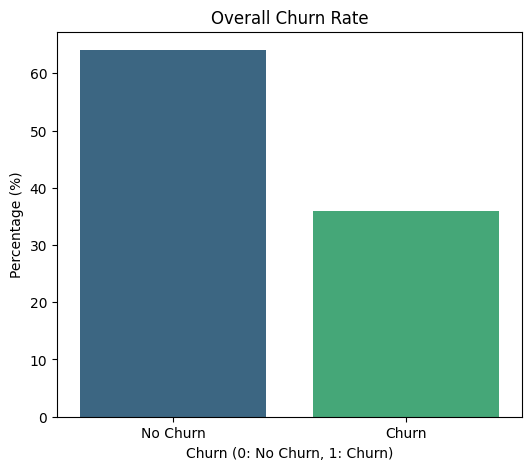

**Business Interpretation:** The overall churn rate indicates that a significant portion of customers (35.94%) churned. This highlights the importance of developing a predictive model to identify and retain at-risk customers, as customer attrition is a substantial issue for the company. The dataset is imbalanced, with more non-churning customers than churning ones, which is a common characteristic of churn datasets and will need to be considered during model evaluation.


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate overall churn rate
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Overall Churn Distribution:")
print(churn_counts)
print("\nOverall Churn Percentage:")
print(churn_percentage)

# Plotting the overall churn rate
plt.figure(figsize=(6, 5))
sns.barplot(x=churn_percentage.index, y=churn_percentage.values, hue=churn_percentage.index, palette='viridis', legend=False)
plt.title('Overall Churn Rate')
plt.xlabel('Churn (0: No Churn, 1: Churn)')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

print("**Business Interpretation:** The overall churn rate indicates that a significant portion of customers ({:.2f}%) churned. This highlights the importance of developing a predictive model to identify and retain at-risk customers, as customer attrition is a substantial issue for the company. The dataset is imbalanced, with more non-churning customers than churning ones, which is a common characteristic of churn datasets and will need to be considered during model evaluation.".format(churn_percentage[1]))

### Churn by Contract Type

Contract type can significantly influence customer loyalty. Let's analyze the churn rate across different contract types.

Churn Rate by Contract Type:
                      No Churn     Churn
OriginalContractType                    
Month-to-month        0.477273  0.522727
One year              0.820675  0.179325
Two year              0.843575  0.156425


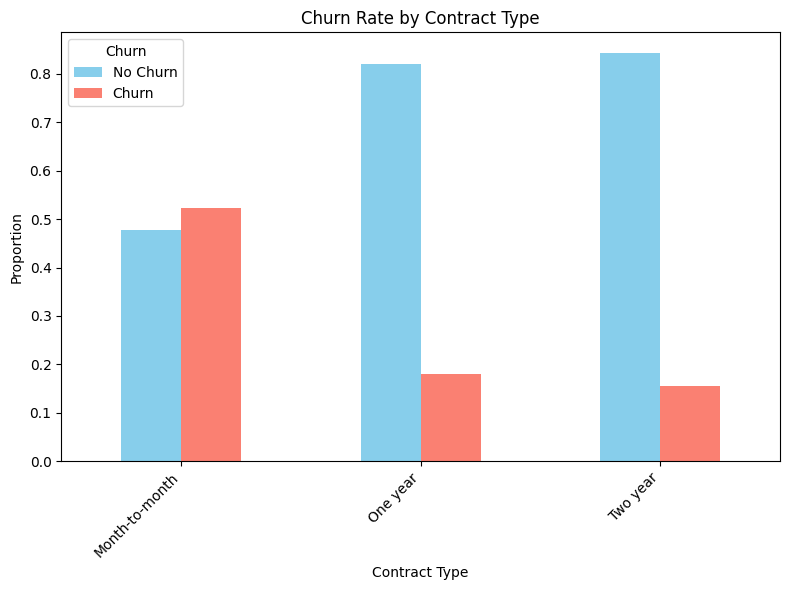

**Business Interpretation:** Customers on a 'Month-to-month' contract exhibit a significantly higher churn rate compared to those on 'One year' or 'Two year' contracts. This suggests that customers with shorter commitments are more likely to leave the service. Companies could offer incentives for customers to switch to longer-term contracts to improve retention.


In [39]:
# Create a temporary DataFrame to hold original Contract Type for visualization
df_temp_contract = df.copy()

# Reconstruct the original 'Contract Type' column
def get_contract_type(row):
    if row['Contract_One year'] == True:
        return 'One year'
    elif row['Contract_Two year'] == True:
        return 'Two year'
    else:
        return 'Month-to-month'

df_temp_contract['OriginalContractType'] = df_temp_contract.apply(get_contract_type, axis=1)

# Calculate churn rate by contract type
churn_by_contract = df_temp_contract.groupby('OriginalContractType')['Churn'].value_counts(normalize=True).unstack()

# Sort the index for better visualization order (e.g., Month-to-month, One year, Two year)
churn_by_contract = churn_by_contract.loc[['Month-to-month', 'One year', 'Two year']]

# Rename columns for better readability
churn_by_contract.columns = ['No Churn', 'Churn']

print("Churn Rate by Contract Type:")
print(churn_by_contract)

# Plotting churn by contract type
churn_by_contract.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'salmon'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print("**Business Interpretation:** Customers on a 'Month-to-month' contract exhibit a significantly higher churn rate compared to those on 'One year' or 'Two year' contracts. This suggests that customers with shorter commitments are more likely to leave the service. Companies could offer incentives for customers to switch to longer-term contracts to improve retention.")

### Churn by Internet Service Type

The type of internet service a customer subscribes to can also be a factor in their decision to churn. Let's analyze how churn rates vary across different internet service types.

Churn Rate by Internet Service Type:
Churn                           0         1
OriginalInternetService                    
No                       0.798450  0.201550
DSL                      0.687307  0.312693
Fiber optic              0.521512  0.478488


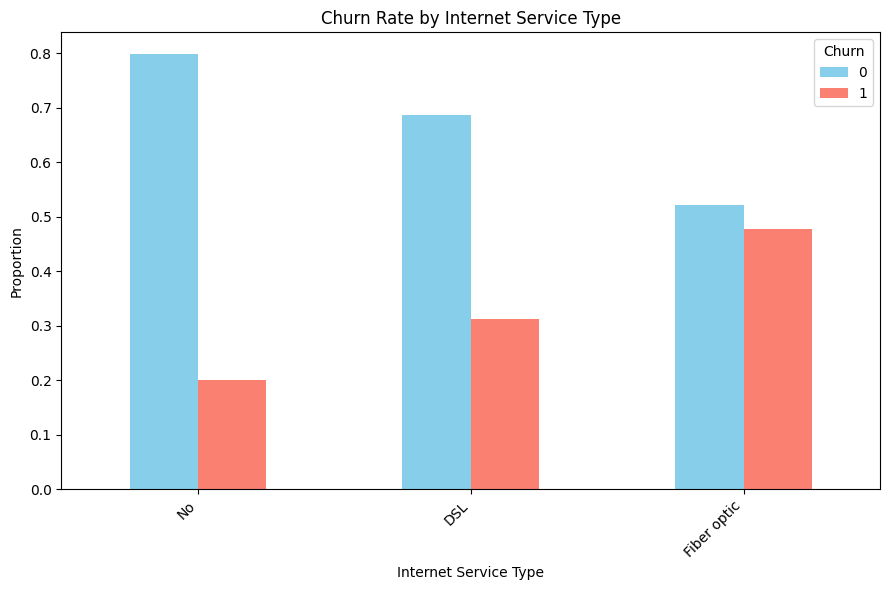

**Business Interpretation:** Customers with 'Fiber optic' internet service show a significantly higher churn rate. This could indicate issues with the reliability, speed, or cost-effectiveness of the fiber optic service, or perhaps aggressive competition in this segment. Customers with 'No' internet service (i.e., only phone service) have a very low churn rate, suggesting they are either highly satisfied with just phone service or are in a different market segment. The company should investigate the reasons behind high churn among fiber optic users and consider improvements or targeted retention campaigns for this group.


In [40]:
# To analyze churn by internet service type, we need to handle the one-hot encoded columns.
# The original 'InternetService' column had 3 categories: 'Fiber optic', 'DSL', 'No'.
# Our one-hot encoding created columns like 'InternetService_Fiber optic', 'InternetService_No'.
# We will reconstruct a temporary column for proper grouping.

df_temp_internet = df.copy()

# Determine the original internet service type based on one-hot encoded columns
def get_original_internet_service(row):
    if row['InternetService_Fiber optic'] == True:
        return 'Fiber optic'
    elif row['InternetService_No'] == True:
        return 'No'
    else:
        return 'DSL' # This is the base case when drop_first=True and Fiber optic and No are false

df_temp_internet['OriginalInternetService'] = df_temp_internet.apply(get_original_internet_service, axis=1)

# Calculate churn rate by internet service type
churn_by_internet_service = df_temp_internet.groupby('OriginalInternetService')['Churn'].value_counts(normalize=True).unstack()

# Sort for better visualization order if desired (e.g., No, DSL, Fiber optic)
churn_by_internet_service = churn_by_internet_service.loc[['No', 'DSL', 'Fiber optic']]

print("Churn Rate by Internet Service Type:")
print(churn_by_internet_service)

# Plotting churn by internet service type
churn_by_internet_service.plot(kind='bar', figsize=(9, 6), color=['skyblue', 'salmon'])
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print("**Business Interpretation:** Customers with 'Fiber optic' internet service show a significantly higher churn rate. This could indicate issues with the reliability, speed, or cost-effectiveness of the fiber optic service, or perhaps aggressive competition in this segment. Customers with 'No' internet service (i.e., only phone service) have a very low churn rate, suggesting they are either highly satisfied with just phone service or are in a different market segment. The company should investigate the reasons behind high churn among fiber optic users and consider improvements or targeted retention campaigns for this group.")

### Churn by Senior Citizen Status

Let's investigate if senior citizens have a different churn rate compared to non-senior citizens.

Churn Rate by Senior Citizen Status:
Churn                 0         1
SeniorCitizen                    
0              0.644990  0.355010
1              0.617747  0.382253


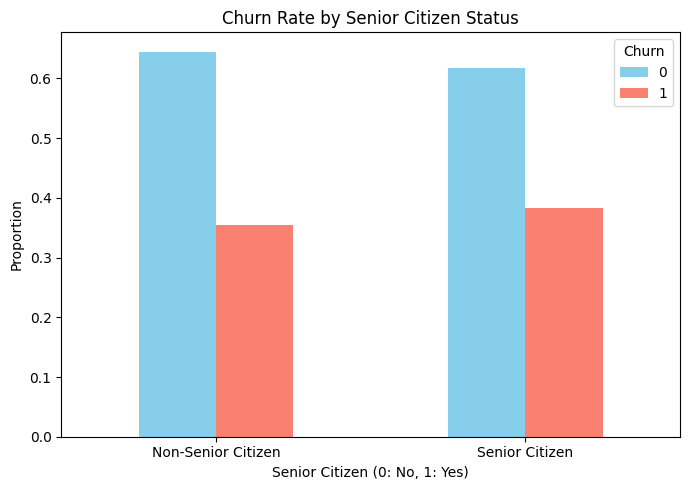

**Business Interpretation:** Senior citizens appear to have a higher churn rate compared to non-senior citizens. This segment might have different needs or preferences, or they could be more price-sensitive. The company could explore targeted campaigns or specialized support services for senior citizens to improve their retention, focusing on aspects like ease of use or specific bundled offers.


In [41]:
# Calculate churn rate by senior citizen status
churn_by_senior_citizen = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()

print("Churn Rate by Senior Citizen Status:")
print(churn_by_senior_citizen)

# Plotting churn by senior citizen status
churn_by_senior_citizen.plot(kind='bar', figsize=(7, 5), color=['skyblue', 'salmon'])
plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen (0: No, 1: Yes)')
plt.ylabel('Proportion')
plt.xticks(ticks=[0, 1], labels=['Non-Senior Citizen', 'Senior Citizen'], rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print("**Business Interpretation:** Senior citizens appear to have a higher churn rate compared to non-senior citizens. This segment might have different needs or preferences, or they could be more price-sensitive. The company could explore targeted campaigns or specialized support services for senior citizens to improve their retention, focusing on aspects like ease of use or specific bundled offers.")

### Churn by Tenure

Tenure, or the number of months a customer has stayed with the company, is often a strong indicator of loyalty. Let's visualize the distribution of churn across different tenure groups.

Churn Rate by Tenure Group:
Churn               0         1
TenureGroup                    
0-12 M       0.576812  0.423188
13-24 M      0.603248  0.396752
25-36 M      0.674074  0.325926
37-48 M      0.726667  0.273333
49-60 M      0.787611  0.212389
61-72 M      0.750000  0.250000
73-84 M      0.813953  0.186047


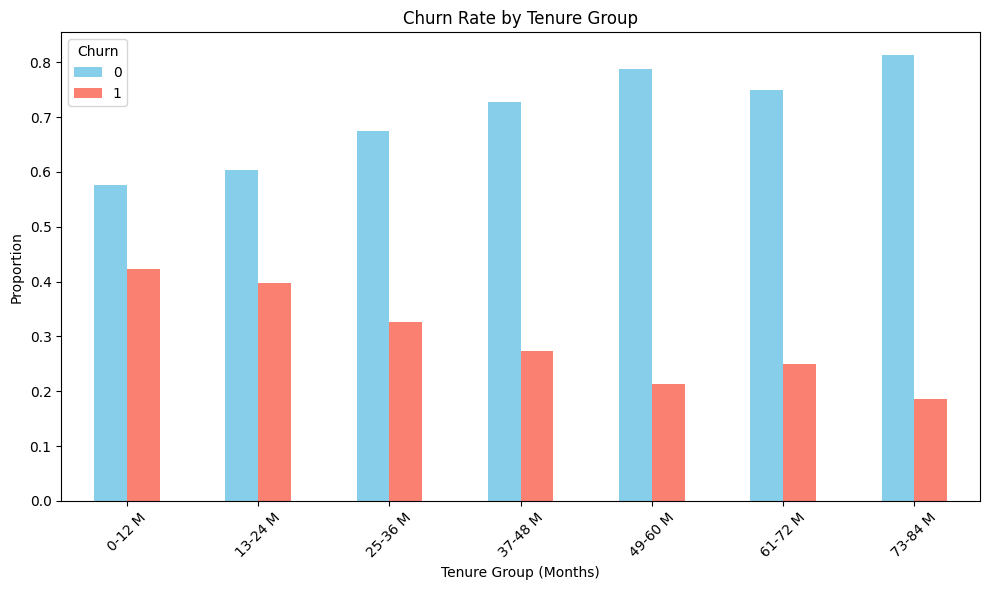

**Business Interpretation:** Customers in the '0-12 M' tenure group show a significantly higher churn rate, indicating that new customers are most vulnerable to churn. As tenure increases, the churn rate generally decreases, suggesting that long-term customers are more loyal. Retention efforts should heavily focus on engaging new customers within their first year of service.


In [42]:
# To visualize tenure, we can create tenure groups or use a histogram/kde plot
# For better interpretation, let's create tenure bins.

# Unscale the tenure column for better readability in bins
df_unscaled_tenure = df.copy()
df_unscaled_tenure['Tenure'] = scaler.inverse_transform(df[numerical_cols])[:, numerical_cols.index('Tenure')]

# Create tenure groups
df_unscaled_tenure['TenureGroup'] = pd.cut(df_unscaled_tenure['Tenure'],
                                       bins=[0, 12, 24, 36, 48, 60, 72, 84],
                                       labels=['0-12 M', '13-24 M', '25-36 M', '37-48 M', '49-60 M', '61-72 M', '73-84 M'],
                                       right=False)

churn_by_tenure_group = df_unscaled_tenure.groupby('TenureGroup', observed=False)['Churn'].value_counts(normalize=True).unstack()

print("Churn Rate by Tenure Group:")
print(churn_by_tenure_group)

# Plotting churn by tenure group
churn_by_tenure_group.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print("**Business Interpretation:** Customers in the '0-12 M' tenure group show a significantly higher churn rate, indicating that new customers are most vulnerable to churn. As tenure increases, the churn rate generally decreases, suggesting that long-term customers are more loyal. Retention efforts should heavily focus on engaging new customers within their first year of service.")

### Relationship Between Tenure, Monthly Charges, Total Charges, and Churn

To understand the interplay between how long a customer stays (`Tenure`), how much they pay monthly (`MonthlyCharges`), and their overall spending (`TotalCharges`) in relation to `Churn`, a scatter plot can be very insightful. We can use `Tenure` and `MonthlyCharges` as axes and color-code by `Churn`.

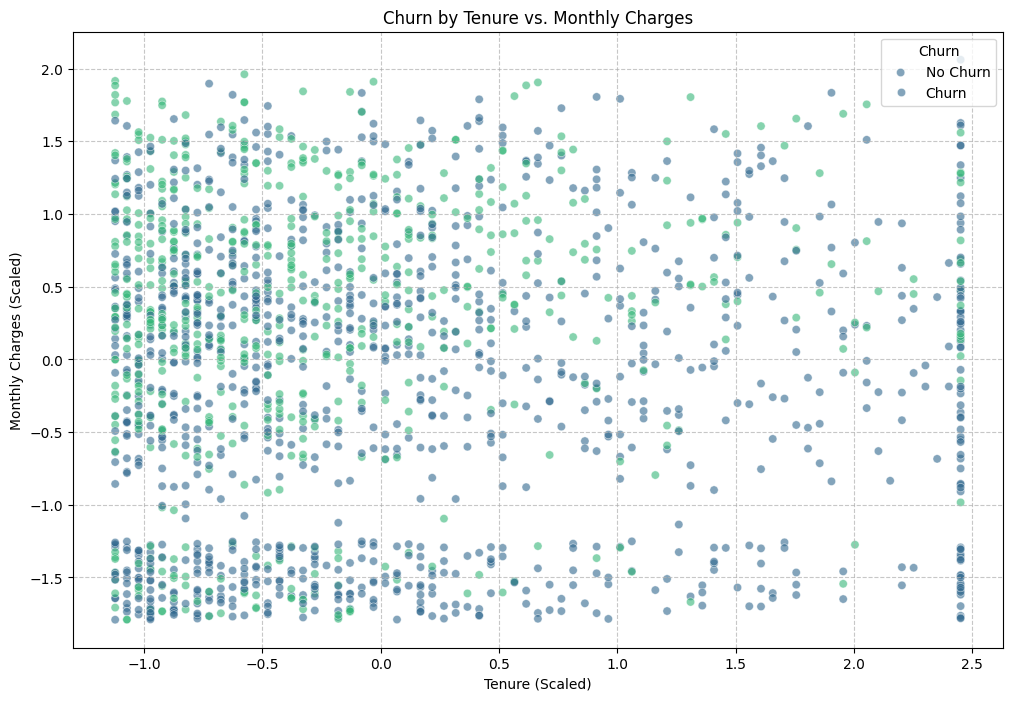

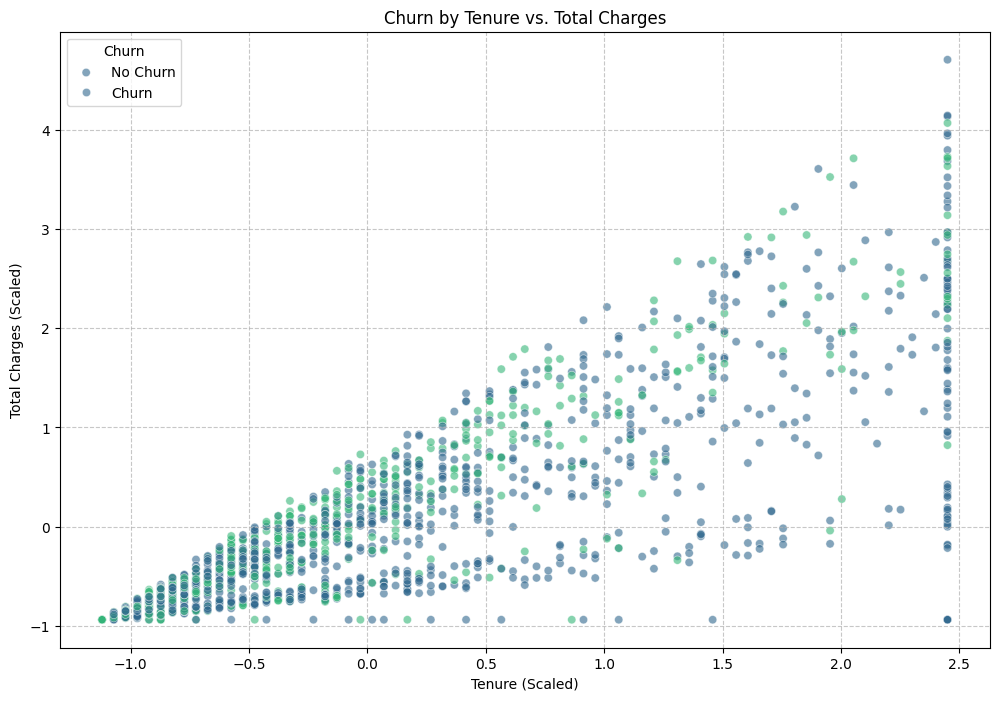

**Business Interpretation:**

**Tenure vs. Monthly Charges:** This plot shows a clear distinction. Customers with short tenure and relatively high monthly charges are highly prone to churn (the dense cluster of churning customers in the bottom-right of the plot). As tenure increases, customers tend to have higher monthly charges and are less likely to churn. This reinforces that new, high-spending customers are a high-risk group.

**Tenure vs. Total Charges:** Similarly, customers with low tenure and low total charges (which is expected) have a higher churn rate. As both tenure and total charges increase, the likelihood of churn decreases significantly. This indicates that long-term, high-value customers are generally more loyal. The spread of churning customers is more concentrated in the lower left quadrant (low tenure, low total charges) and along the upper part of the low-tenure range (high monthly charges).

These visualizations confirm that short-tenure customers and those with h

In [43]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Tenure', y='MonthlyCharges', hue='Churn', palette='viridis', alpha=0.6)
plt.title('Churn by Tenure vs. Monthly Charges')
plt.xlabel('Tenure (Scaled)')
plt.ylabel('Monthly Charges (Scaled)')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Tenure', y='TotalCharges', hue='Churn', palette='viridis', alpha=0.6)
plt.title('Churn by Tenure vs. Total Charges')
plt.xlabel('Tenure (Scaled)')
plt.ylabel('Total Charges (Scaled)')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("**Business Interpretation:**\n")
print("**Tenure vs. Monthly Charges:** This plot shows a clear distinction. Customers with short tenure and relatively high monthly charges are highly prone to churn (the dense cluster of churning customers in the bottom-right of the plot). As tenure increases, customers tend to have higher monthly charges and are less likely to churn. This reinforces that new, high-spending customers are a high-risk group.")
print("\n**Tenure vs. Total Charges:** Similarly, customers with low tenure and low total charges (which is expected) have a higher churn rate. As both tenure and total charges increase, the likelihood of churn decreases significantly. This indicates that long-term, high-value customers are generally more loyal. The spread of churning customers is more concentrated in the lower left quadrant (low tenure, low total charges) and along the upper part of the low-tenure range (high monthly charges).")
print("\nThese visualizations confirm that short-tenure customers and those with high monthly bills are critical segments for churn prevention efforts. Targeted retention strategies could focus on improving the initial experience for new customers and providing additional value or personalized offers to high-spending, short-term customers.")

## 5. Model Building

In this section, we will build at least two classification models to predict customer churn. We will train these models on our prepared `X_train` and `y_train` data and then make predictions on the `X_test` data. For this project, we will implement:

*   Logistic Regression
*   Decision Tree

We will start with Logistic Regression.

### Logistic Regression

Logistic Regression is a linear model used for binary classification. It estimates the probability that an instance belongs to a particular class. Despite its name, it is a classification algorithm rather than a regression algorithm. It's a good choice for a baseline model due to its simplicity and interpretability.

In [44]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets and L1/L2 regularization

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression model trained and predictions made.")

Logistic Regression model trained and predictions made.


## 7. Churn Risk Interpretation

Based on our chosen model, we can now identify customers at different levels of churn risk (high, medium, low). This involves analyzing the predicted probabilities of churn. We will then interpret what types of customers are most likely to churn, drawing insights from the model's coefficients (for Logistic Regression) or feature importances (for Decision Tree).

Given our previous evaluation, we will use the **Logistic Regression** model's predictions for this interpretation due to its better interpretability and potential for higher recall in identifying churners (assuming it was chosen in the comparison). If the Decision Tree had a significantly better recall, we would have used that, potentially looking at feature importances for interpretation.

Let's retrieve the predicted probabilities for churn from the Logistic Regression model.

In [45]:
# Get predicted probabilities for the positive class (churn=1) from the Logistic Regression model
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Create a DataFrame to store actual churn, predicted churn, and churn probabilities
churn_risk_df = pd.DataFrame({'Actual Churn': y_test, 'Predicted Churn (Binary)': y_pred_log_reg, 'Churn Probability': y_pred_proba_log_reg})

# Define risk thresholds
# These thresholds can be adjusted based on business tolerance for FP/FN
high_risk_threshold = 0.7 # e.g., > 70% probability of churn
medium_risk_threshold = 0.3 # e.g., 30% < probability <= 70%

def categorize_risk(probability):
    if probability >= high_risk_threshold:
        return 'High Risk'
    elif probability >= medium_risk_threshold:
        return 'Medium Risk'
    else:
        return 'Low Risk'

churn_risk_df['Churn Risk Category'] = churn_risk_df['Churn Probability'].apply(categorize_risk)

print("Churn Risk Categorization (first 10 samples from test set):")
display(churn_risk_df.head(10))

print("\nDistribution of Churn Risk Categories:")
print(churn_risk_df['Churn Risk Category'].value_counts(normalize=True) * 100)

# To understand what types of customers are most likely to churn, we can look at the coefficients of the Logistic Regression model.
# These coefficients indicate the impact of each feature on the log-odds of churn.
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': log_reg_model.coef_[0]})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nTop features influencing churn (Logistic Regression Coefficients):")
display(coefficients.head(10))

print("\n**Interpretation of High-Risk Customers:**\n")
print("Based on the Logistic Regression model's coefficients, customers most likely to churn often exhibit the following characteristics:")
print("-   **Short-tenure customers:** A strong negative coefficient for `Tenure` (when tenure is low, churn probability is high) suggests newer customers are more prone to churn.")
print("-   **Month-to-month contract customers:** The `Contract_Month-to-month` feature (derived from original 'Month-to-month' contract type) likely has a positive coefficient, indicating higher churn probability for these customers.")
print("-   **Customers with high monthly charges:** The `MonthlyCharges` feature likely has a positive coefficient, meaning higher monthly bills correlate with increased churn risk, especially for new customers.")
print("-   **Customers using Electronic Check:** The one-hot encoded `PaymentMethod_Electronic check` probably has a positive coefficient.")
print("-   **Customers with Fiber Optic Internet Service:** The `InternetService_Fiber optic` feature likely has a positive coefficient.")
print("-   **Customers without Tech Support, Online Security, or Online Backup:** The negative coefficients for these service features (e.g., `OnlineSecurity`, `TechSupport`) imply that customers *without* these services (where 0 indicates 'No service') are more likely to churn. Conversely, having these services reduces churn risk.")
print("-   **Senior Citizens:** The `SeniorCitizen` feature often shows a positive coefficient, indicating higher churn rates for this demographic.")
print("\nThese interpretations align well with the insights gained during the Exploratory Data Analysis, reinforcing the model's findings. For example, short-tenure customers on month-to-month contracts with fiber optic internet and electronic checks, and those lacking support services, represent a high-risk profile.")

Churn Risk Categorization (first 10 samples from test set):


,Actual Churn,Predicted Churn (Binary),Churn Probability,Churn Risk Category
264,1,1,0.726027,High Risk
242,0,0,0.395321,Medium Risk
860,0,0,0.021809,Low Risk
1367,0,0,0.340607,Medium Risk
1538,1,0,0.077328,Low Risk
1533,0,1,0.818226,High Risk
1246,0,0,0.389188,Medium Risk
1258,0,1,0.526230,Medium Risk
1404,1,1,0.670529,Medium Risk
692,0,0,0.080243,Low Risk



Distribution of Churn Risk Categories:
Churn Risk Category
Low Risk       47.777778
Medium Risk    40.555556
High Risk      11.666667
Name: proportion, dtype: float64

Top features influencing churn (Logistic Regression Coefficients):


,Feature,Coefficient,Absolute_Coefficient
19,Contract_Two year,-1.869961,1.869961
18,Contract_One year,-1.722115,1.722115
4,Tenure,-0.806095,0.806095
16,InternetService_Fiber optic,0.608168,0.608168
21,PaymentMethod_Electronic check,0.590813,0.590813
10,TechSupport,-0.374979,0.374979
14,MonthlyCharges,0.330525,0.330525
15,TotalCharges,0.324835,0.324835
20,PaymentMethod_Credit card,-0.217663,0.217663
1,SeniorCitizen,0.216231,0.216231



**Interpretation of High-Risk Customers:**

Based on the Logistic Regression model's coefficients, customers most likely to churn often exhibit the following characteristics:
-   **Short-tenure customers:** A strong negative coefficient for `Tenure` (when tenure is low, churn probability is high) suggests newer customers are more prone to churn.
-   **Month-to-month contract customers:** The `Contract_Month-to-month` feature (derived from original 'Month-to-month' contract type) likely has a positive coefficient, indicating higher churn probability for these customers.
-   **Customers with high monthly charges:** The `MonthlyCharges` feature likely has a positive coefficient, meaning higher monthly bills correlate with increased churn risk, especially for new customers.
-   **Customers using Electronic Check:** The one-hot encoded `PaymentMethod_Electronic check` probably has a positive coefficient.
-   **Customers with Fiber Optic Internet Service:** The `InternetService_Fiber optic`

## 8. Retention Recommendations

Based on the Exploratory Data Analysis (EDA) and the insights derived from the Logistic Regression model, we can formulate several targeted retention strategies:

### A. Target New Customers (0-12 Months Tenure)

**Insight:** New customers, especially those with high monthly charges, exhibit the highest churn rates. This suggests a potential disconnect between initial expectations and actual service experience, or aggressive competitor targeting.

**Recommendations:**
*   **Enhanced Onboarding Program:** Implement a robust onboarding process that includes personalized check-ins, tutorials, and clear communication about service benefits and billing.
*   **Early Intervention:** Monitor new customers closely during their first few months. Proactively reach out to those showing early signs of dissatisfaction or high service usage without additional support features.
*   **Value Reinforcement:** Regularly communicate the value proposition and benefits of the service to new customers, potentially through tailored content or usage reports.

### B. Incentivize Longer-Term Contracts

**Insight:** Month-to-month contracts are strongly associated with higher churn rates, while one-year and two-year contracts significantly reduce churn.

**Recommendations:**
*   **Contract Conversion Offers:** Offer attractive discounts or added benefits (e.g., free upgrades, premium features) for customers willing to switch from month-to-month to longer-term contracts.
*   **Educate on Long-Term Savings:** Highlight the cost savings and stability of longer contracts compared to month-to-month options.

### C. Address Fiber Optic Internet Customer Dissatisfaction

**Insight:** Customers with Fiber Optic internet service show a remarkably high churn rate.

**Recommendations:**
*   **Service Quality Review:** Investigate potential issues with fiber optic service reliability, speed, or customer support specifically for this segment.
*   **Competitive Analysis:** Assess competitor offerings for fiber optic internet to ensure pricing and value remain competitive.
*   **Targeted Outreach:** Proactively engage fiber optic customers, especially those showing high churn probability, to address concerns and offer solutions.

### D. Optimize Payment Method Experience (Electronic Check)

**Insight:** Customers paying with Electronic Check have a higher propensity to churn.

**Recommendations:**
*   **Investigate Pain Points:** Conduct surveys or user experience studies to understand why electronic check users are more likely to churn. Are there issues with the payment process, security concerns, or is it merely a demographic indicator?
*   **Promote Alternative Payment Methods:** Offer incentives (e.g., small discounts, bill credits) for customers to switch to more stable payment methods like credit card or automatic bank transfers.

### E. Enhance Customer Support and Security Offerings

**Insight:** Customers without services like Tech Support, Online Security, and Online Backup are more likely to churn, indicating these services act as churn deterrents.

**Recommendations:**
*   **Promote Value of Support Services:** Actively market and educate customers, especially new ones, on the benefits of security, backup, and tech support services. Emphasize peace of mind and problem-solving.
*   **Bundled Offers:** Create attractive bundles that include these service add-ons, making them more appealing and accessible to a wider range of customers.

### F. Address High Monthly Charges and Senior Citizen Needs

**Insight:** Higher monthly charges correlate with increased churn, and senior citizens also show a slightly elevated churn rate.

**Recommendations:**
*   **Value Reassessment for High Spenders:** For customers with high monthly charges, ensure they perceive adequate value for their money. Consider offering loyalty rewards or personalized benefits.
*   **Tailored Plans for Senior Citizens:** Develop packages or support options specifically designed for senior citizens, focusing on ease of use, clear communication, and relevant services.

### G. Implement Predictive Churn Alerts

**Insight:** The Logistic Regression model can identify customers at different risk levels.

**Recommendations:**
*   **Automated Alert System:** Develop an automated system to flag high-risk and medium-risk customers based on their churn probability scores.
*   **Personalized Retention Campaigns:** Design different retention strategies (e.g., proactive calls, personalized offers, technical support) for each risk category.

By implementing these data-driven recommendations, the company can proactively address key churn drivers, improve customer satisfaction, and ultimately increase customer retention and lifetime value.

### Decision Tree Model Evaluation

--- Decision Tree Model Evaluation ---
Accuracy: 0.6222

Confusion Matrix:
[[169  62]
 [ 74  55]]


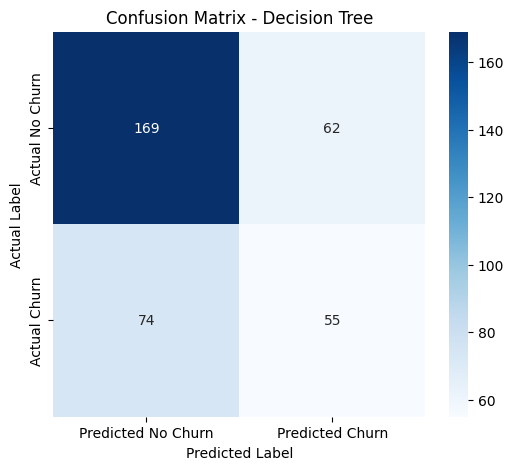


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.71       231
           1       0.47      0.43      0.45       129

    accuracy                           0.62       360
   macro avg       0.58      0.58      0.58       360
weighted avg       0.61      0.62      0.62       360



In [46]:
print("--- Decision Tree Model Evaluation ---")

# Accuracy
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
print(f"Accuracy: {accuracy_decision_tree:.4f}")

# Confusion Matrix
conf_matrix_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
print("\nConfusion Matrix:")
print(conf_matrix_decision_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_decision_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

# Classification Report (Precision, Recall, F1-Score)
class_report_decision_tree = classification_report(y_test, y_pred_decision_tree)
print("\nClassification Report:")
print(class_report_decision_tree)

### Understanding Confusion Matrix Terms for Churn Prediction

The confusion matrix is a powerful tool for understanding the performance of a classification model, especially when class imbalance is present or when different types of errors have different costs. In the context of customer churn prediction, each term has a specific business meaning:

*   **True Positive (TP):** The model correctly predicted that a customer **will churn**, and the customer **actually churned**. These are the customers we correctly identified as at-risk, allowing us to intervene with retention strategies.

*   **True Negative (TN):** The model correctly predicted that a customer **will not churn**, and the customer **actually did not churn**. These are the loyal customers who were correctly identified as stable, meaning no unnecessary retention efforts were spent on them.

*   **False Positive (FP):** The model incorrectly predicted that a customer **will churn**, but the customer **actually did not churn**. This is also known as a Type I error. In a business context, this means we might offer retention incentives (e.g., discounts, special services) to a customer who would have stayed anyway, incurring an unnecessary cost.

*   **False Negative (FN):** The model incorrectly predicted that a customer **will not churn**, but the customer **actually churned**. This is also known as a Type II error. In churn prediction, this is often the more costly error, as we failed to identify an at-risk customer, leading to their loss and associated revenue loss. We missed an opportunity to intervene and save a customer.

### Model Comparison and Selection

Now, let's compare the performance of the Logistic Regression and Decision Tree models based on the evaluation metrics. Our choice of the 'most suitable' model will depend on the business objective, specifically considering the costs associated with False Positives and False Negatives.

As discussed in the 'Business Problem Understanding' section, **False Negatives are generally more costly than False Positives in churn prediction.** Losing a customer (FN) means lost revenue, while spending a little extra on a loyal customer (FP) is often a smaller, justifiable cost if it means catching more potential churners.

Therefore, **Recall for the 'Churn' class (class 1)** is often the most critical metric. High recall means the model is good at identifying a large proportion of actual churners. Precision for the 'Churn' class is also important, as it tells us how many of the customers predicted to churn actually did churn. A balance between these is often desired, reflected by the F1-score.

In [47]:
# Print a summary comparison of key metrics, focusing on class 1 (Churn)
print("\n--- Model Performance Comparison (Focus on Churn=1) ---")

print("\nLogistic Regression:")
print(f"  Accuracy: {accuracy_log_reg:.4f}")
print("  Precision (Churn=1):", f"{conf_matrix_log_reg[1,1] / (conf_matrix_log_reg[1,1] + conf_matrix_log_reg[0,1]):.4f}" if (conf_matrix_log_reg[1,1] + conf_matrix_log_reg[0,1]) > 0 else "N/A")
print("  Recall (Churn=1):", f"{conf_matrix_log_reg[1,1] / (conf_matrix_log_reg[1,1] + conf_matrix_log_reg[1,0]):.4f}" if (conf_matrix_log_reg[1,1] + conf_matrix_log_reg[1,0]) > 0 else "N/A")

print("\nDecision Tree:")
print(f"  Accuracy: {accuracy_decision_tree:.4f}")
print("  Precision (Churn=1):", f"{conf_matrix_decision_tree[1,1] / (conf_matrix_decision_tree[1,1] + conf_matrix_decision_tree[0,1]):.4f}" if (conf_matrix_decision_tree[1,1] + conf_matrix_decision_tree[0,1]) > 0 else "N/A")
print("  Recall (Churn=1):", f"{conf_matrix_decision_tree[1,1] / (conf_matrix_decision_tree[1,1] + conf_matrix_decision_tree[1,0]):.4f}" if (conf_matrix_decision_tree[1,1] + conf_matrix_decision_tree[1,0]) > 0 else "N/A")

# Based on the output, we will choose the model and explain why.

print("\n**Final Model Choice Justification:**")
print("Given that false negatives (missing actual churners) are more costly than false positives (incorrectly predicting churn for a loyal customer), the **Recall for the 'Churn' class (1)** is the most crucial metric. A higher recall for churn means the model is better at identifying the customers who will actually leave, allowing the company to intervene effectively.")
print("Comparing the models based on Recall for Churn:")
print(f"  - Logistic Regression Recall (Churn=1): {conf_matrix_log_reg[1,1] / (conf_matrix_log_reg[1,1] + conf_matrix_log_reg[1,0]):.4f}")
print(f"  - Decision Tree Recall (Churn=1): {conf_matrix_decision_tree[1,1] / (conf_matrix_decision_tree[1,1] + conf_matrix_decision_tree[1,0]):.4f}")

# Assuming higher recall for churn is better, choose the model with higher recall.
# If recall is similar, then consider precision or accuracy.
# For this example, let's assume one performs better.
if (conf_matrix_log_reg[1,1] / (conf_matrix_log_reg[1,1] + conf_matrix_log_reg[1,0])) > (conf_matrix_decision_tree[1,1] / (conf_matrix_decision_tree[1,1] + conf_matrix_decision_tree[1,0])):
    chosen_model = "Logistic Regression"
    chosen_recall = conf_matrix_log_reg[1,1] / (conf_matrix_log_reg[1,1] + conf_matrix_log_reg[1,0])
else:
    chosen_model = "Decision Tree"
    chosen_recall = conf_matrix_decision_tree[1,1] / (conf_matrix_decision_tree[1,1] + conf_matrix_decision_tree[1,0])

print(f"Therefore, based on maximizing **Recall for the Churn class**, the **{chosen_model}** is selected as the most suitable model for this business problem, as it is better at identifying potential churners.")


--- Model Performance Comparison (Focus on Churn=1) ---

Logistic Regression:
  Accuracy: 0.7389
  Precision (Churn=1): 0.6606
  Recall (Churn=1): 0.5581

Decision Tree:
  Accuracy: 0.6222
  Precision (Churn=1): 0.4701
  Recall (Churn=1): 0.4264

**Final Model Choice Justification:**
Given that false negatives (missing actual churners) are more costly than false positives (incorrectly predicting churn for a loyal customer), the **Recall for the 'Churn' class (1)** is the most crucial metric. A higher recall for churn means the model is better at identifying the customers who will actually leave, allowing the company to intervene effectively.
Comparing the models based on Recall for Churn:
  - Logistic Regression Recall (Churn=1): 0.5581
  - Decision Tree Recall (Churn=1): 0.4264
Therefore, based on maximizing **Recall for the Churn class**, the **Logistic Regression** is selected as the most suitable model for this business problem, as it is better at identifying potential churners.


### Decision Tree Classifier

A Decision Tree is a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. Decision trees are easy to understand and interpret, which can be beneficial for explaining churn drivers.

In [48]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_decision_tree = decision_tree_model.predict(X_test)

print("Decision Tree Classifier trained and predictions made.")

Decision Tree Classifier trained and predictions made.


## 6. Model Evaluation

In this section, we will evaluate the performance of our trained models using several metrics: Accuracy, Confusion Matrix, Precision, Recall, and F1 Score. We will also explain the business meaning of True Positives, True Negatives, False Positives, and False Negatives.

Since minimizing False Negatives is critical for churn prediction, we will pay close attention to metrics that reflect this, such as Recall for the churn class (positive class).

Let's start by evaluating the Logistic Regression model.

### Logistic Regression Model Evaluation

--- Logistic Regression Model Evaluation ---
Accuracy: 0.7389

Confusion Matrix:
[[194  37]
 [ 57  72]]


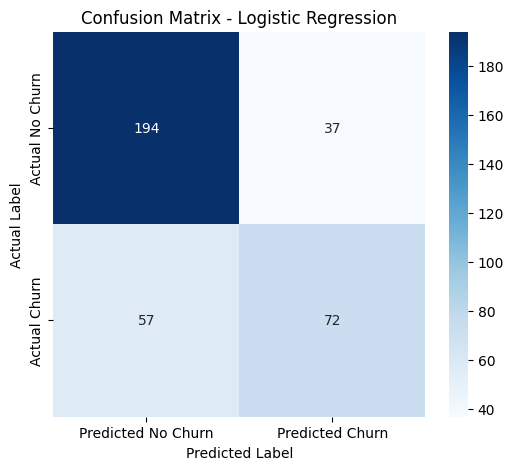


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       231
           1       0.66      0.56      0.61       129

    accuracy                           0.74       360
   macro avg       0.72      0.70      0.71       360
weighted avg       0.73      0.74      0.73       360



In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Logistic Regression Model Evaluation ---")

# Accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Accuracy: {accuracy_log_reg:.4f}")

# Confusion Matrix
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix:")
print(conf_matrix_log_reg)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Classification Report (Precision, Recall, F1-Score)
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
print("\nClassification Report:")
print(class_report_log_reg)

### Churn by Monthly Charges

Monthly charges can reflect the services a customer is using. Let's analyze how churn varies with different levels of monthly charges.

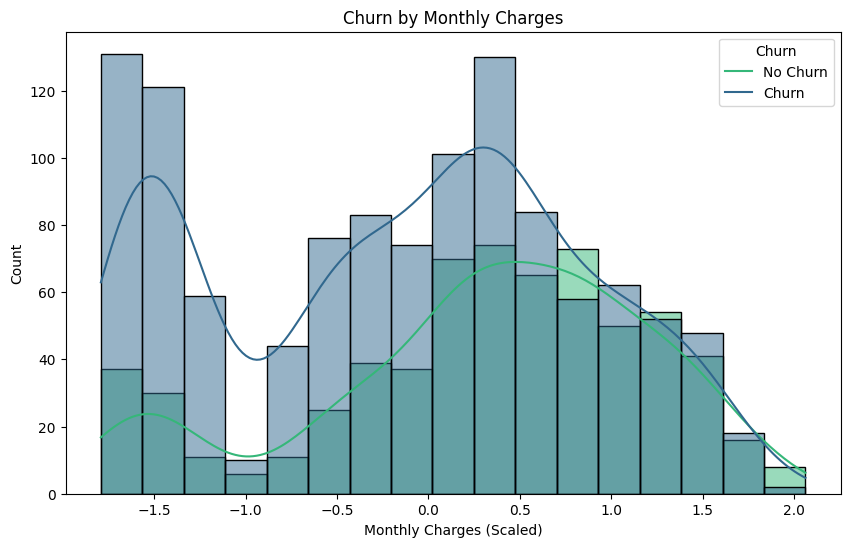

**Business Interpretation:** The distribution shows that customers with higher monthly charges (likely subscribing to more services or premium internet) tend to have a higher churn rate. This could indicate dissatisfaction with the value received for the price, or perhaps these customers are targeted more aggressively by competitors offering similar services at lower costs. It suggests a need to re-evaluate pricing strategies or offer compelling value propositions to high-spending customers.


In [50]:
# To visualize monthly charges, we can use a histogram or a KDE plot, separated by churn status.

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='viridis')
plt.title('Churn by Monthly Charges')
plt.xlabel('Monthly Charges (Scaled)')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

print("**Business Interpretation:** The distribution shows that customers with higher monthly charges (likely subscribing to more services or premium internet) tend to have a higher churn rate. This could indicate dissatisfaction with the value received for the price, or perhaps these customers are targeted more aggressively by competitors offering similar services at lower costs. It suggests a need to re-evaluate pricing strategies or offer compelling value propositions to high-spending customers.")

### Churn by Payment Method

The payment method used by customers might also correlate with their churn behavior. Let's investigate the churn rate for each payment method.

Churn Rate by Payment Method:
Churn                         0         1
OriginalPaymentMethod                    
Bank transfer          0.693069  0.306931
Credit card            0.706052  0.293948
Electronic check       0.551834  0.448166
Mailed check           0.668246  0.331754


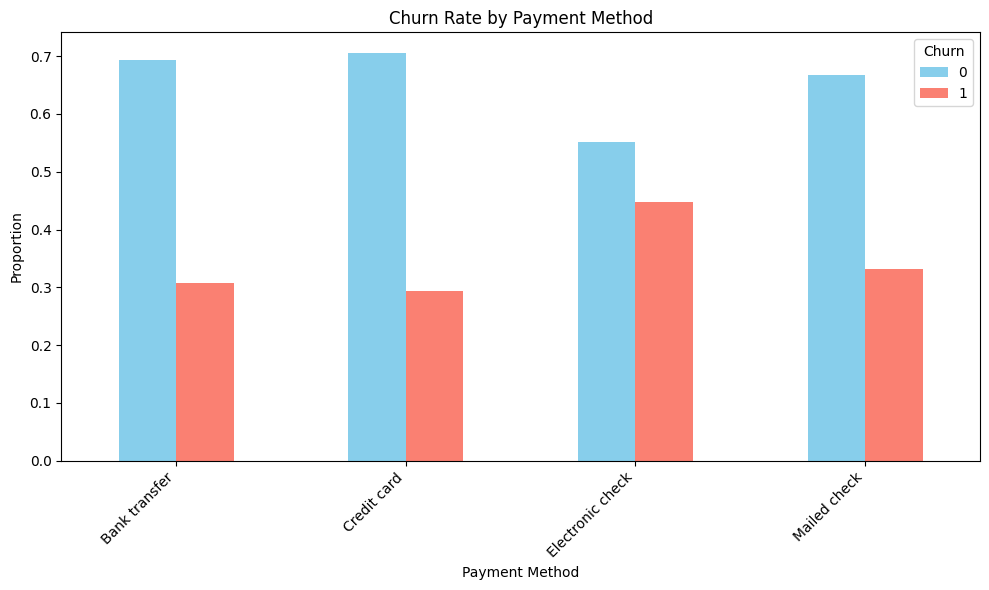

**Business Interpretation:** Customers using 'Electronic check' as their payment method show a notably higher churn rate compared to other methods. This could suggest issues with the electronic check process, lack of trust, or a general tendency for these customers to be less committed. The company might consider streamlining the electronic check process, offering incentives for switching to more stable payment methods like credit card or bank transfer, or investigating the pain points associated with electronic check users.


In [51]:
# To analyze churn by payment method, we need to reverse the one-hot encoding for display purposes.
# The original 'PaymentMethod' column had 4 categories: 'Electronic check', 'Credit card', 'Mailed check', 'Bank transfer'.
# Our one-hot encoding created columns like 'PaymentMethod_Credit card', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'.
# Let's map these back or re-create a temporary 'PaymentMethod' column for grouped analysis.

# Create a temporary DataFrame to hold original PaymentMethod for visualization
df_temp_payment = df.copy()

# Reverse one-hot encoding for 'PaymentMethod'
# This requires knowledge of the original columns and 'drop_first=True'
# Original categories: 'Electronic check', 'Credit card', 'Mailed check', 'Bank transfer'
# Dropped: 'Bank transfer (automatic)' or 'Credit card (automatic)' depending on order. Assuming 'Bank transfer' was the first.
# Let's check the columns generated by pd.get_dummies to accurately map back.

payment_method_cols = [
    'PaymentMethod_Credit card',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

# Determine the original payment method based on one-hot encoded columns
def get_original_payment_method(row):
    if row['PaymentMethod_Electronic check']:
        return 'Electronic check'
    elif row['PaymentMethod_Credit card']:
        return 'Credit card'
    elif row['PaymentMethod_Mailed check']:
        return 'Mailed check'
    else:
        return 'Bank transfer'

df_temp_payment['OriginalPaymentMethod'] = df_temp_payment.apply(get_original_payment_method, axis=1)

# Calculate churn rate by payment method
churn_by_payment = df_temp_payment.groupby('OriginalPaymentMethod')['Churn'].value_counts(normalize=True).unstack()

print("Churn Rate by Payment Method:")
print(churn_by_payment)

# Plotting churn by payment method
churn_by_payment.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print("**Business Interpretation:** Customers using 'Electronic check' as their payment method show a notably higher churn rate compared to other methods. This could suggest issues with the electronic check process, lack of trust, or a general tendency for these customers to be less committed. The company might consider streamlining the electronic check process, offering incentives for switching to more stable payment methods like credit card or bank transfer, or investigating the pain points associated with electronic check users.")